                                                            Лабораторна 1
Хід роботи
    1. Викачати та підготувати дані
        a. Завантажити датасет за допомогою функції fetch_openml.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [3]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

            b. Вивести форму матриці X і кількість унікальних міток у y.

In [4]:
print(f"Форма матриці X: {X.shape}") 
print(f"Унікальні мітки: {np.unique(y)}") 

Форма матриці X: (70000, 784)
Унікальні мітки: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


            c. Для попереднього огляду візуалізувати кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів.

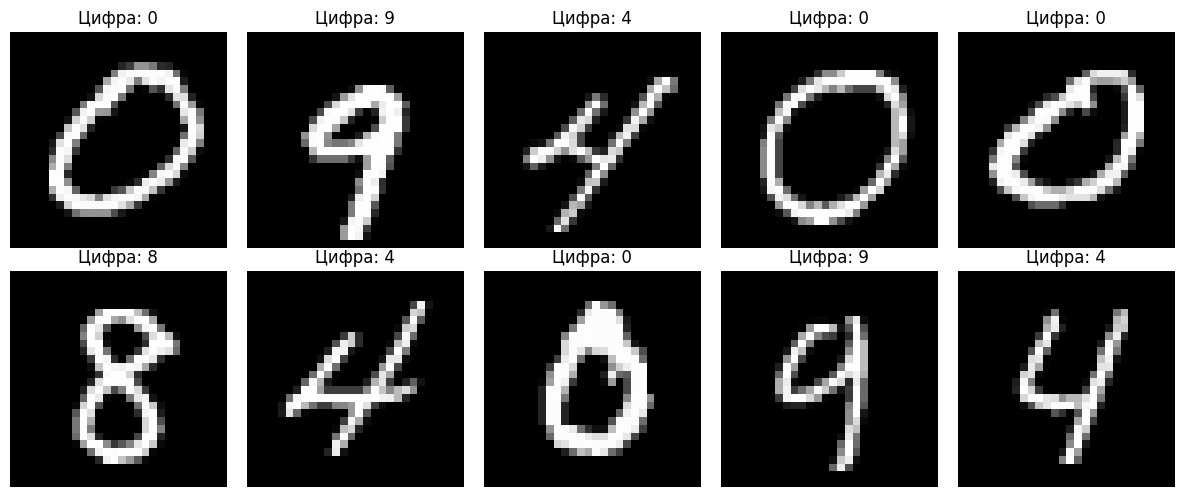

In [5]:
plt.figure(figsize=(12, 5))
for i in range(10):
    idx = np.random.randint(0, X.shape[0])
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Цифра: {y[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

    2. Реалізувати метод головних компонент (PCA)
        a. Реалізувати PCA із кількістю компонент n_components=3.

In [6]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

        b. Отримати матрицю проєкцій (X_pca) розміром (70000 × 3);

        c. Вивести відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_).

In [7]:
explained_variance = pca.explained_variance_ratio_
print(f"Відсоток поясненої дисперсії: {explained_variance}")
print(f"Загалом збережено інформації: {np.sum(explained_variance)*100:.2f}%")

Відсоток поясненої дисперсії: [0.09746116 0.07155445 0.06149531]
Загалом збережено інформації: 23.05%


    3. Візуалізувати дані у просторі перших трьох компонент
        a. Побудувати 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використати matplotlib.axes3d або plotly). Точки зафарбувати відповідно до класу цифри.


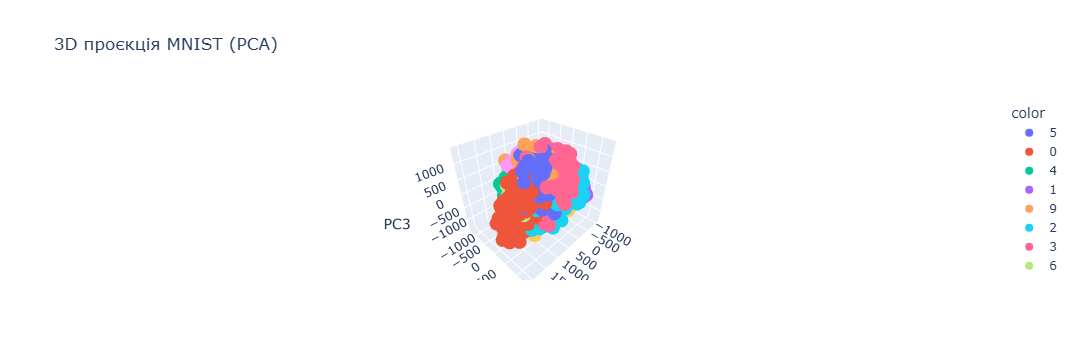

In [8]:
fig = px.scatter_3d(
    x=X_pca[:5000, 0], y=X_pca[:5000, 1], z=X_pca[:5000, 2],
    color=y[:5000], 
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
    title="3D проєкція MNIST (PCA)"
)
fig.show()

        b. Проаналізувати, чи видно кластери для різних цифр, наскільки добре PCA відділяє класи у тривимірному просторі.
Кластери різних цифр добре видно, що показує, те що PCA добре відділяє класи у тривимірному просторі.

    4. Реконструкція зображень після зменшення розмірності
        a. Використати метод inverse_transform() з PCA для відновлення даних із простору трьох компонент у оригінальний простір.

In [9]:
X_restored = pca.inverse_transform(X_pca)

        b. Вивести кілька прикладів (наприклад, 10 випадкових цифр):
            i. оригінальне зображення;
            ii. реконструйоване після PCA з трьома компонентами.


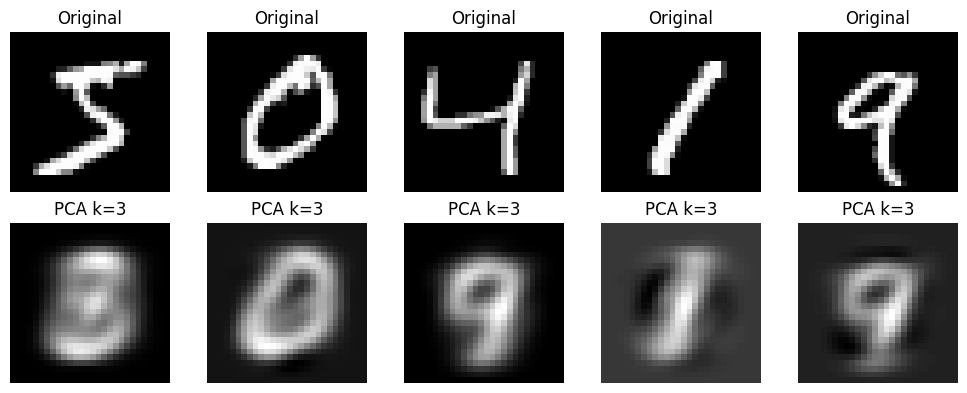

In [10]:
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(X_restored[i].reshape(28, 28), cmap='gray')
    plt.title("PCA k=3")
    plt.axis('off')
plt.tight_layout()
plt.show()

    5. Проаналізувати залежність між помилкою реконструкції та кількістю компонент
        a. Визначити помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями
        пікселів.


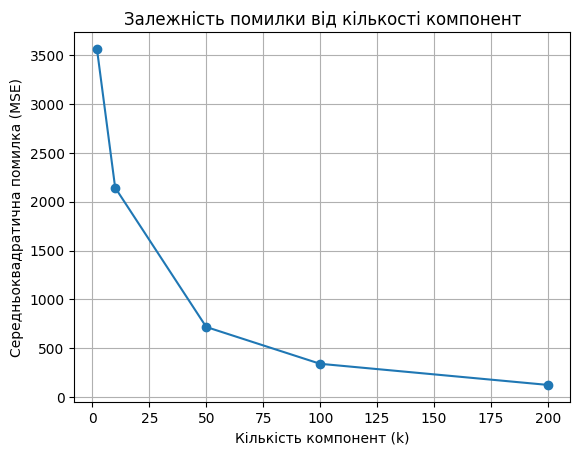

In [11]:
k_values = [2, 10, 50, 100, 200]
mse_list = []

for k in k_values:
    pca_k = PCA(n_components=k)
    X_reduced = pca_k.fit_transform(X[:2000])
    X_rec = pca_k.inverse_transform(X_reduced)
    mse_list.append(mean_squared_error(X[:2000], X_rec))

plt.plot(k_values, mse_list, 'o-')
plt.xlabel("Кількість компонент (k)")
plt.ylabel("Середньоквадратична помилка (MSE)")
plt.title("Залежність помилки від кількості компонент")
plt.grid(True)
plt.show()